In [77]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Plot style
sns.set_style("whitegrid")
%matplotlib inline

In [42]:
DATA_PATH = 'data/UCS-Satellite-Database 5-1-2023 (text).txt'

df = pd.read_csv(DATA_PATH, sep='\t', header=0, encoding='latin1', engine='python')

print('Data shape:', df.shape)
print('Columns:')
for i,c in enumerate(df.columns):
    print(i, repr(c))

has_starlink= True

Data shape: (7562, 68)
Columns:
0 'Name of Satellite, Alternate Names'
1 'Current Official Name of Satellite'
2 'Country/Org of UN Registry'
3 'Country of Operator/Owner'
4 'Operator/Owner'
5 'Users'
6 'Purpose'
7 'Detailed Purpose'
8 'Class of Orbit'
9 'Type of Orbit'
10 'Longitude of GEO (degrees)'
11 'Perigee (km)'
12 'Apogee (km)'
13 'Eccentricity'
14 'Inclination (degrees)'
15 'Period (minutes)'
16 'Launch Mass (kg.)'
17 ' Dry Mass (kg.) '
18 'Power (watts)'
19 'Date of Launch'
20 'Expected Lifetime (yrs.)'
21 'Contractor'
22 'Country of Contractor'
23 'Launch Site'
24 'Launch Vehicle'
25 'COSPAR Number'
26 'NORAD Number'
27 'Comments'
28 'Unnamed: 28'
29 'Source Used for Orbital Data'
30 'Source'
31 'Source.1'
32 'Source.2'
33 'Source.3'
34 'Source.4'
35 'Source.5'
36 'Source.6'
37 'Unnamed: 37'
38 'Unnamed: 38'
39 'Unnamed: 39'
40 'Unnamed: 40'
41 'Unnamed: 41'
42 'Unnamed: 42'
43 'Unnamed: 43'
44 'Unnamed: 44'
45 'Unnamed: 45'
46 'Unnamed: 46'
47 'Unnamed: 47'
48 'Unnamed: 48'


In [43]:
# Remove starlink satellites
print('Shape before removing Starlink:', df.shape)
df = df[~df['Current Official Name of Satellite'].str.contains('Starlink', na=False, case=False)]
print('Shape after removing Starlink:', df.shape)
has_starlink = False

Shape before removing Starlink: (7562, 68)
Shape after removing Starlink: (3566, 68)


In [44]:
candidates = [c for c in df.columns if 'Launch Mass' in str(c) or 'LaunchMass' in str(c).replace(' ', '') or 'Launch mass' in str(c)]
print('Launch mass column candidates:', candidates)

if not candidates:
    raise ValueError('Could not find a Launch Mass column automatically. Check column names printed above.')

launch_col = candidates[0]
print('Using column:', repr(launch_col))

s = df[launch_col].astype(str).copy()
s = s.str.replace(',', '', regex=False).str.strip()
s_num = s.str.extract(r'([0-9]+?[0-9eE+-]*)')[0]  # may produce NaN for non-matching
df['launch_mass_kg'] = pd.to_numeric(s_num, errors='coerce')

print('Parsed launch_mass_kg: non-null count =', df['launch_mass_kg'].notna().sum())
df['launch_mass_kg'].describe()

Launch mass column candidates: ['Launch Mass (kg.)']
Using column: 'Launch Mass (kg.)'
Parsed launch_mass_kg: non-null count = 3319


count     3319.000000
mean      1060.096716
std       1971.749858
min          1.000000
25%         10.000000
50%        148.000000
75%       1000.000000
max      22500.000000
Name: launch_mass_kg, dtype: float64

Saved figure to launch_mass_histogram_no_starlink.pdf


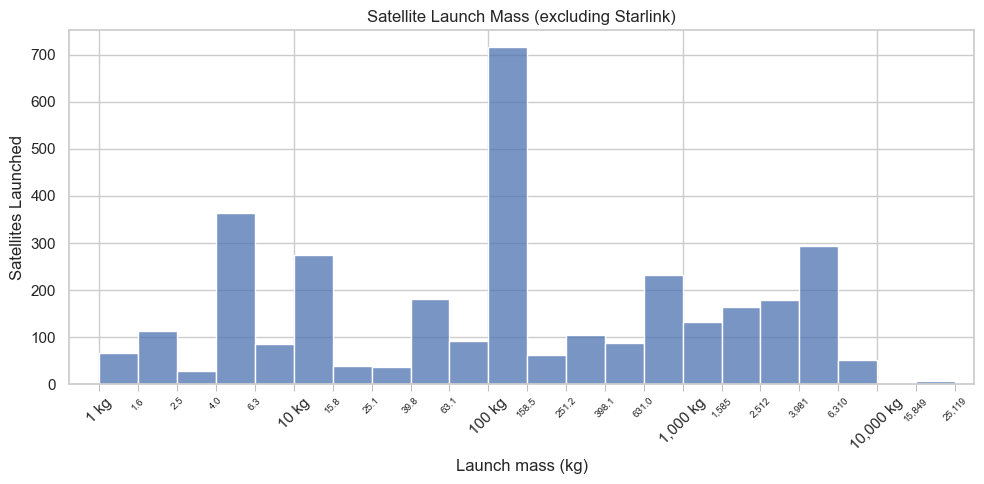

In [90]:
# Draw a histogram and show a nicely-formatted log-x axis (plain numbers + intermediate ticks).
vals = df['launch_mass_kg'].dropna()

plt.figure(figsize=(10,5))

sns.histplot(vals, binwidth=0.2, log_scale=(True, False))
ax = plt.gca()
import matplotlib.ticker as mticker
ax.set_xscale('log')
ax.xaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=[10**0.2, 10**0.4, 10**0.6, 10**0.8]))

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f} kg"))


ax.xaxis.set_minor_formatter(mticker.StrMethodFormatter("{x:,.1f}"))
ax.xaxis.set_minor_formatter(mticker.FuncFormatter(lambda x, pos: f'' if x < 1 or x > 26e3 else f'{x:,.1f}' if x < 1000 else f'{x:,.0f}'))


ax.tick_params(axis='x', which='major', rotation=45)
ax.tick_params(axis='x', which='minor', labelsize=7, rotation=45)
ax.tick_params(axis='x', which='both', length=5, width=0.8, color='0.75', bottom=True)
ax.set_xlim(0.7, vals.max()*1.4)
plt.xlabel('Launch mass (kg)')
plt.ylabel('Satellites Launched')
plt.title('Satellite Launch Mass {}'.format('' if has_starlink else '(excluding Starlink)'))
plt.tight_layout()

filename = 'launch_mass_histogram{}.pdf'.format('' if has_starlink else '_no_starlink')
plt.savefig(filename, dpi=300)
print('Saved figure to', filename)

plt.show()


In [49]:
# Save diagram

plt.savefig(filename, dpi=300)
print('Saved figure to', filename)

Saved figure to launch_mass_histogram_no_starlink.pdf


<Figure size 640x480 with 0 Axes>